### Определение орбиты виртуального астероида методом Лапласа

In [3]:
from math import *
import numpy as np
from datetime import datetime
from astropy.time import Time

import matplotlib.pyplot as plt
%matplotlib widget

### Матрицы вращения

In [4]:
def rotx(psi):
    return np.array([[1,0,0],[0,cos(psi),sin(psi)],[0,-sin(psi),cos(psi)]])

def roty(psi):
    return np.array([[cos(psi),0,-sin(psi)],[0,1,0],[sin(psi),0,cos(psi)]])

def rotz(psi):
    return np.array([[cos(psi),sin(psi),0],[-sin(psi),cos(psi),0],[0,0,1]])


### Теперь нужна функция для перехода от координат и скоростей к элементам орбиты

In [5]:
def orbital_elem(x,y,z,xdot,ydot,zdot):
    r = np.array([x,y,z])
    rdot = np.array([xdot,ydot,zdot])
    #modules of r and rdot vectors
    R = np.linalg.norm(r)
    RDOT = np.linalg.norm(rdot)
    #double sectorial velocity
    c = np.array([y*zdot-z*ydot,z*xdot-x*zdot,x*ydot-y*xdot])
    C = np.linalg.norm(c)

    a = 1 / (2/R-RDOT**2) # semi-major axis
    p = C**2 # focal parameter

    e = sqrt(1-p/a) # eccentricity
    u = atan2(RDOT*C,p/R-1.0) # true anomaly
    # eccentric anomaly
    E = atan2(R*sin(u)/a/sqrt(1-e**2),R*cos(u)/a+e)
    M = E - e*sin(E) # mean anomaly
    P = 2*pi*a**(3/2) # period
    n = a**(-3/2) # mean motion
    T = - M / n # perihelion epoch
    #inclination
    i = atan2(sqrt(c[0]**2+c[1]**2)/C,c[2]/C)
    # longitude of the ascending node
    Omega = atan2(c[0]/C/sin(i),-c[1]/C/sin(i))
    rorb = np.dot(rotx(i),r)
    omegaPlus_u = atan2(rorb[1]/R,rorb[0]/R)
    omega = omegaPlus_u - u # argument of periapsis
    return a,e,P,T,i,Omega,omega

### Нам надо уметь решать уравнение Кеплера

In [6]:
def KeplerEquation(e, P, T, t):
    n = 2 * pi / P
    E = M = n * (t - T)
    epsilon = pi/(180*3600000)
    while (fabs(E - e * sin(E) - M) > epsilon):
        E = M + e * sin(E)
    return E

### А еще нам надо уметь вычислять компоненты гелиоцентрического радиуса-вектора если задан момент времени $t$ и орбитальные элементы

In [7]:
def xyz(a,e,P,T,i,Omega, omega,t):   # defining heliocentric coordinates
    E = KeplerEquation(e,P,T,t)
    ksi = a*(cos(E)-e)
    eta = a*sqrt(1-e**2)*sin(E)
    r = np.array([ksi, eta, 0])
#     return np.linalg.multi_dot([rotz(-Omega),rotx(-i),rotz(-omega),r])
    return np.dot(rotz(-Omega),np.dot(rotx(-i),np.dot(rotz(-omega),r)))

def xyz0(r0,n0,t,t0):# Geocenter heliocentric coordinates
    return np.array([r0*cos(n0*(t-t0)),r0*sin(n0*(t-t0)),0])

### Гелиоцентрические положение и скорость центра Земли на какой-то произвольный момент введем как показано ниже. Для координат единицей измерения является астрономическая единица, а для скоростей за единицу принимается круговая скорость движения Земли по гелиоцентрической орбите ($V \approx 29844.9$~м/с).

In [8]:
x0 = 1; y0 = 0; z0 =0; x0dot = 0; y0dot = 1; z0dot = 0;
speed_of_light = 10045# в скоростях Земли

### Для тестирования мы поработаем с неким модельным астероидом. Его орбита определяется декартовыми гелиоцентрическими координатами и их первыми производными по времени (компонентами скорости)

In [9]:
x = -4.42886945; y = 0.48312824; z = 0.48312824 # au
xdot = -0.30709289; ydot = -0.27567732; zdot = -0.27567732 # в скоростях Земли

In [10]:
a,e,P,T,i,Omega,omega = orbital_elem(x,y,z,xdot,ydot,zdot)
print(a,e,P,T,i,Omega,omega)
xyz(a,e,P,T,i,Omega, omega,0)

4.999979434670494 0.4999994190489907 70.24771390796393 -8.579950626908065 0.7853981633974483 0.0 1.2495385790004652


array([-4.16348444,  0.32559174,  0.32559174])

#### Моделируем наблюдения

In [11]:
delta_t = 0.005 # шаг по времени между наблюдениями
a,e,P,T,i,Omega,omega = orbital_elem(x,y,z,xdot,ydot,zdot)

N = 10

lon,lat,tau = np.zeros(N),np.zeros(N),np.zeros(N)

for k in range(N):
    t = 1 + k*delta_t  #observational time
    t_real = t - np.linalg.norm(xyz(a,e,P,T,i,Omega, omega,t)-xyz0(1,1,t,0))/speed_of_light# планетная аберрация
#     print(t_real-t)
    xyz_real = xyz(a,e,P,T,i,Omega, omega,t_real)-xyz0(1,1,t_real,0)# геоцентрическое положение
    rho = np.linalg.norm(xyz_real)
#     print(xyz(a,e,P,T,i,Omega, omega,t_real))
    urho = xyz_real/rho
    b = atan2(urho[2],sqrt(urho[0]**2+urho[1]**2))
    l = atan2(urho[1]/cos(b),urho[0]/cos(b))
    tau[k] = t
    lat[k] = b
    lon[k] = l
    print('time = %5.3f'%t,'lambda = %5.3f'%degrees(l),'beta = %5.4f'%degrees(b))
lat+=np.random.normal(0,radians(0.1/3600),N)
lon+=np.random.normal(0,radians(0.1/3600),N)

time = 1.000 lambda = -170.622 beta = 0.2158
time = 1.005 lambda = -170.569 beta = 0.1984
time = 1.010 lambda = -170.517 beta = 0.1811
time = 1.015 lambda = -170.464 beta = 0.1637
time = 1.020 lambda = -170.412 beta = 0.1462
time = 1.025 lambda = -170.359 beta = 0.1288
time = 1.030 lambda = -170.307 beta = 0.1114
time = 1.035 lambda = -170.255 beta = 0.0939
time = 1.040 lambda = -170.204 beta = 0.0764
time = 1.045 lambda = -170.152 beta = 0.0589


In [12]:
fig,ax = plt.subplots(1,figsize=(1.5, 1.5), dpi=300)

ax.scatter(np.degrees(lon),np.degrees(lat),  c='black',  s=0.3, linewidths=0.5)
ax.set_xlabel('$\\lambda$ (deg)', fontsize = 6)
ax.set_ylabel('$\\beta$ (deg)', fontsize = 6)

ax.tick_params(axis='both', which='major', labelsize=4)
ax.tick_params(axis='both', which='minor', labelsize=4)
ax.ticklabel_format(useOffset=False)

plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

#### Определяем параметры видимого движения с помощью МНК

$\lambda = \lambda(t_0)+\dot \lambda(t-t_0)+0.5\ddot \lambda (t-t_0)^2$

In [13]:
C = np.ones((N,3))
meant = np.mean(tau)
for j in range(N):
    C[j,1]=tau[j]- meant
    C[j,2]=0.5*(tau[j]- meant)**2

Lat = np.dot(np.linalg.inv(np.dot(C.T,C)),np.dot(C.T,lat))
Lon = np.dot(np.linalg.inv(np.dot(C.T,C)),np.dot(C.T,lon))

res = lat-np.dot(C,Lat)
uwe = np.dot(res.T,res)/(N-3)
D = uwe*np.linalg.inv(np.dot(C.T,C))
# print(Lat,Lon)
3600*np.degrees(res),3600*degrees(sqrt(uwe))

(array([-0.03491011,  0.09944808, -0.0016114 , -0.12241133, -0.05154826,
         0.12299704,  0.09917779, -0.1778061 ,  0.08818604, -0.02152176]),
 0.11561788529240792)

### Реализация метода Лапласа по книге О.П. Быкова, К.В. Холшевникова Прямые методы определения орбит небесных тел – СПб, 2013. – 151 с. ISBN 978-5-288-05393-1 http://www.astro.spbu.ru/sites/default/files/Bykoff.pdf

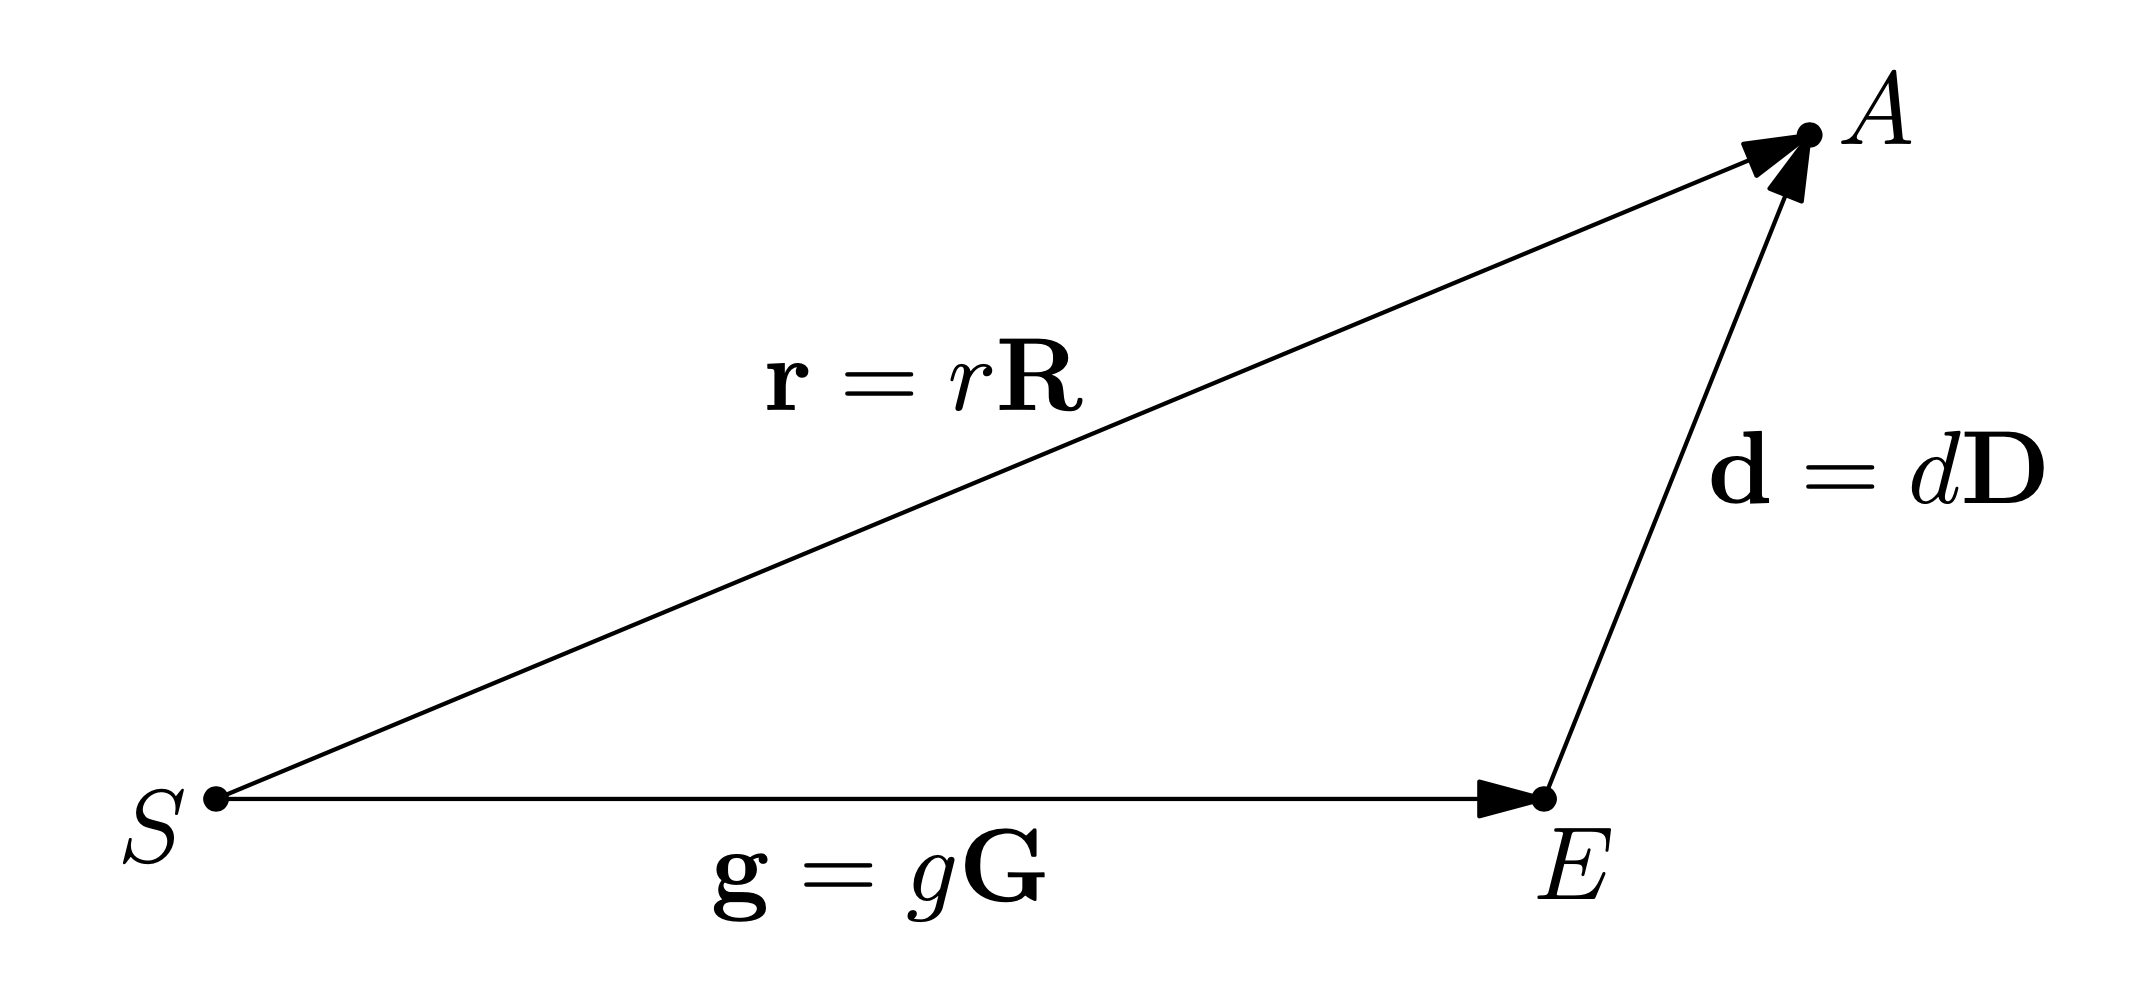

In [14]:
from IPython.display import Image 
pil_img = Image(filename='to_solve_Laplace.png', width = 400)
display(pil_img)

$\mathbf{r} =  d\mathbf{D}+ \mathbf{g} $

$\mathbf{\dot r} =   \dot d \mathbf{D}+ d  \mathbf{\dot D}+  \mathbf{\dot g}$

$\mathbf{\ddot r} =   \ddot d \mathbf{D}+ 2\dot d \mathbf{\dot D}+ d \mathbf{\ddot D}+ \mathbf{\ddot g}$

$\mathbf{\ddot r} = -k^2\frac{\mathbf{r}}{r^3}$

$d\mathbf{D} = \mathbf{r} - \mathbf{g} $

$\dot d \mathbf{D}+ d  \mathbf{\dot D} =  \mathbf{\dot r} -  \mathbf{\dot g}$

$\left(\mathbf{\ddot D}+\frac{k^2}{r^3}\mathbf{\dot D} \right)d + 2\mathbf{\dot D} \dot d +  \mathbf{D}\ddot d = -\frac{k^2}{r^3}\mathbf{\dot g}-\mathbf{\ddot g}$

Нам известны $\mathbf{D},\mathbf{\dot D},\mathbf{\dot D} $

Из первого уравнения выразим $r^2$

$r^2 = C_0+2C_1d+d^2$, $C_0=g^2$, $C_1=\mathbf{g}\mathbf{D}$

Обе части третьего уравнения умножаем на $\mathbf{D}\times\mathbf{\dot D}$ скалярно

$Cd = C_2+C_3 r^{-3}$

$C = (\mathbf{ D}\mathbf{\dot D}\mathbf{\ddot D})$, $C_2 = -(\mathbf{ D}\mathbf{\dot D}\mathbf{\ddot g})$, $C_3 = -k^2(\mathbf{ D}\mathbf{\dot D}\mathbf{g})$

Итог этих тяжких приключений - два уравнения, из которых надо выразить $r$ и $d$

$r^2 = C_0+2C_1d+d^2$ и $Cd = C_2+C_3 r^{-3}$

Если поколдовать с этими уравнениями, то они сведутся вот к чему:

$C^2r^8 + a_6 r^2+a_3r^3 + a_0 = 0$

$C^2 d^8 +b_7d^7+b_6d^6+\ldots +b_0=0$

Блок кода ниже дает представление о том, как из комбинаций $C,C_0,C_1,C_3$ строятся $a_6, a_3, a_0$, как решаются уравнения.

In [15]:
#координаты и их производные
l = Lon[0];dotl = Lon[1];ddotl = Lon[2]
b = Lat[0];dotb = Lat[1];ddotb = Lat[2]
# единичный вектор геоцентрического положения астероида
er = np.array([cos(l)*cos(b),sin(l)*cos(b),sin(b)])
# единичный вектор геоцентрического положения астероида, первая производная
dot_er = dotl*np.array([-sin(l)*cos(b),cos(l)*cos(b),0])+\
            dotb*np.array([-cos(l)*sin(b),-sin(l)*sin(b),cos(b)])
# единичный вектор геоцентрического положения астероида, вторая производная
ddot_er = ddotl*np.array([-sin(l)*cos(b),cos(l)*cos(b),0])+\
            ddotb*np.array([-cos(l)*sin(b),-sin(l)*sin(b),cos(b)])-\
          (dotl**2)*np.array([cos(l)*cos(b),sin(l)*cos(b),0])-\
            (dotb**2)*np.array([cos(l)*cos(b),sin(l)*cos(b),sin(b)])+\
            2*(dotl*dotb)*np.array([sin(l)*sin(b),-cos(l)*sin(b),0])

# гелиоцентрическое положение геоцентра на момент meant - средний момент наблюдений
g = xyz0(1,1,meant,0)
#вычисление констант
C0 = np.dot(g,g)
C1 = np.dot(g,er)
C = np.linalg.det(np.array([er,dot_er,ddot_er]))
C2 = -np.linalg.det(np.array([er,dot_er,-g/(np.linalg.norm(g)**3)]))
C3 = -np.linalg.det(np.array([er,dot_er,g]))
a0 = -(C3**2)
a3 = -2*(C2+C1*C)*C3
a6 = -((C**2)*C0+2*C*C1*C2+(C2**2))
#решение уравнения (корни)
Roots2 = np.roots(np.array([C**2,0,a6,0,0,a3,0,0,a0]))

r = np.real(Roots2)[np.argmax(np.real(Roots2))]

print('geliocentric distance =%f'%(r))


rho = (C2+C3*r**(-3))/C
print('geocentric distance =%f'%(rho))
#radial velocity (derevative of geocentric distance)
dot_rho = ((r**-3)*np.linalg.det(np.array([er,ddot_er,g]))+np.linalg.det(np.array([er,ddot_er,-g/(np.linalg.norm(g)**3)])))

#velocity of the Earth
dot_g = np.array([-sin(meant),cos(meant),0])

r = g + rho*er
dot_r = dot_g + rho*dot_er + dot_rho*er
# print('true orbit a,e,P,T,i,Omega,omega\n',orbital_elem(x,y,z,xdot,ydot,zdot))
# print(r[0],r[1],r[2],dot_r[0],dot_r[1],dot_r[2])
# print('preliminary orbit a,e,P,T,i,Omega,omega\n',orbital_elem(r[0],r[1],r[2],dot_r[0],dot_r[1],dot_r[2]))

geocentric distance =4.303021
geocentric distance =4.892826
